# Preprocessing

## 1. Setup

This cell sets paths, imports the feature-extraction helpers, and keeps the notebook connected to the local `src/` package. If you edit the script, rerun this cell so the notebook picks up the new version.

In [4]:
# imports
from pathlib import Path
import sys
from importlib import reload

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.eeg_utils
reload(src.eeg_utils)

import matplotlib.pyplot as plt
import mne
import pandas as pd

from pyprep.prep_pipeline import PrepPipeline
from mne.preprocessing import ICA
from src.eeg_utils import crop_rest_conditions, load_rest_eeg, plot_psd_comparison


## 2. Line-noise inspection and removal

- Before final band-pass filtering, PSD was inspected up to `100 Hz` to assess whether a `50 Hz` line-noise peak was present.
- Line-noise removal was then applied using MNE's notch filtering with `method="spectrum_fit"`, which is similar to the PREP-style selective removal of narrowband electrical contamination.
- PSD was then checked again after denoising before taking the signal forward into the rest of preprocessing.


In [5]:
# Load subject 1 resting EEG and split into eyes-open / eyes-closed segments
raw = load_rest_eeg("../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr", preload=True)
raw_eyes_open, raw_eyes_closed, markers = crop_rest_conditions(raw)

print(markers)
print(f"Eyes-open duration: {raw_eyes_open.times[-1]:.2f} s")
print(f"Eyes-closed duration: {raw_eyes_closed.times[-1]:.2f} s")


Extracting parameters from ../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 661519  =      0.000 ...   661.519 secs...
{'eyes_open_start': 23.323, 'eyes_open_end': 264.701, 'eyes_closed_start': 276.067, 'eyes_closed_end': 637.358}
Eyes-open duration: 241.38 s
Eyes-closed duration: 361.29 s


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/sub-01_rest_eyes_open_line_noise_before.png


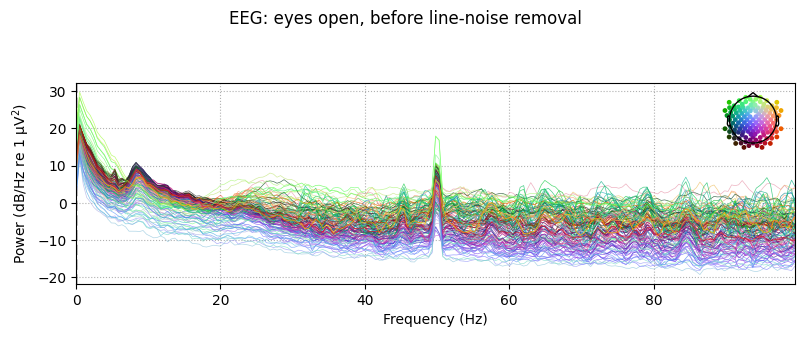

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/sub-01_rest_eyes_closed_line_noise_before.png


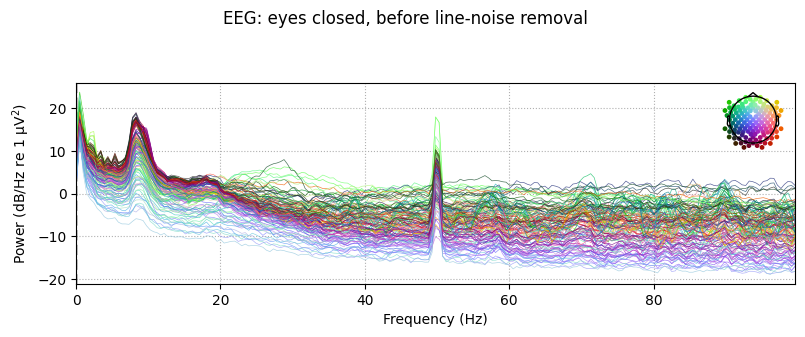

In [6]:
# Check PSD before line-noise removal, extending to 100 Hz to inspect 50 Hz contamination
def plot_condition_psd(raw_condition, *, title, save_name):
    fig = raw_condition.plot_psd(fmax=100, average=False, show=False)
    fig.suptitle(title)
    for ax in fig.axes:
        if ax.get_title() == "EEG":
            ax.set_title("")
    fig.tight_layout()

    save_path = project_root / "figures" / "exploratory" / save_name
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(save_path)
    return fig

fig_open_before = plot_condition_psd(
    raw_eyes_open,
    title="EEG: eyes open, before line-noise removal",
    save_name="sub-01_rest_eyes_open_line_noise_before.png",
)
plt.show()

fig_closed_before = plot_condition_psd(
    raw_eyes_closed,
    title="EEG: eyes closed, before line-noise removal",
    save_name="sub-01_rest_eyes_closed_line_noise_before.png",
)
plt.show()


In [7]:
# Apply line-noise removal at 50 Hz before band-pass filtering
raw_eyes_open_denoised = raw_eyes_open.copy().notch_filter(
    freqs=[50],
    method="spectrum_fit",
    filter_length="10s"
)

raw_eyes_closed_denoised = raw_eyes_closed.copy().notch_filter(
    freqs=[50],
    method="spectrum_fit",
    filter_length="10s"
)


Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 5969 windows
Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 9017 windows


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/sub-01_rest_eyes_open_line_noise_after.png


/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


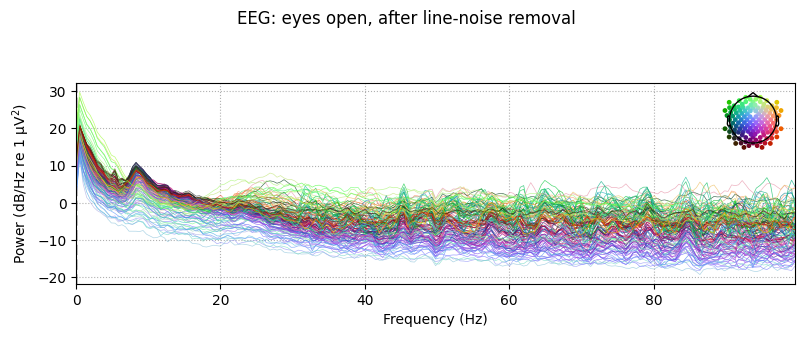

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/sub-01_rest_eyes_closed_line_noise_after.png


/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_82547/3642088888.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


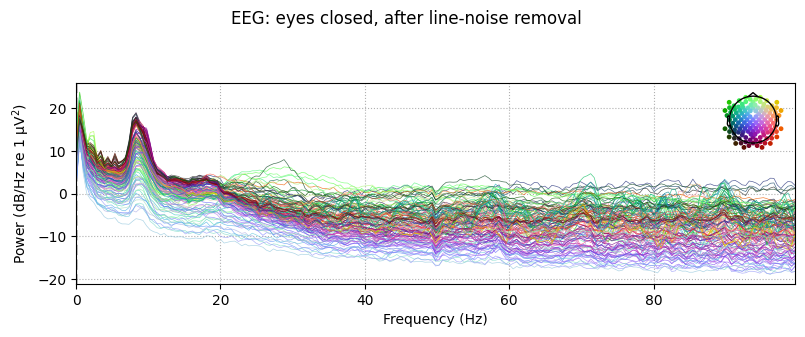

In [8]:
# Check PSD again after line-noise removal
fig_open_after = plot_condition_psd(
    raw_eyes_open_denoised,
    title="EEG: eyes open, after line-noise removal",
    save_name="sub-01_rest_eyes_open_line_noise_after.png",
)
plt.show()

fig_closed_after = plot_condition_psd(
    raw_eyes_closed_denoised,
    title="EEG: eyes closed, after line-noise removal",
    save_name="sub-01_rest_eyes_closed_line_noise_after.png",
)
plt.show()


## 3. Resampling

- After line-noise removal, the eyes-open and eyes-closed segments are resampled from `1000 Hz` to `250 Hz`.
- This reduces the number of time points by a factor of four, which makes later steps such as PREP, ICA, epoching, and later quality-control steps substantially faster.
- A single `1-40 Hz` filtered branch is created after PREP-style channel cleaning and used for ICA-oriented preprocessing and PSD quality checks.


In [9]:
# Resample the denoised data to 250 Hz before later preprocessing steps
raw_eyes_open_resampled = raw_eyes_open_denoised.copy().resample(250)
raw_eyes_closed_resampled = raw_eyes_closed_denoised.copy().resample(250)

print(raw_eyes_open_resampled)
print(raw_eyes_closed_resampled)
print(f"Resampled sampling rate: {raw_eyes_open_resampled.info['sfreq']} Hz")


<RawBrainVision | sub-01_task-rest_eeg.eeg, 127 x 60345 (241.4 s), ~58.6 MiB, data loaded>
<RawBrainVision | sub-01_task-rest_eeg.eeg, 127 x 90323 (361.3 s), ~87.7 MiB, data loaded>
Resampled sampling rate: 250.0 Hz


Using matplotlib as 2D backend.


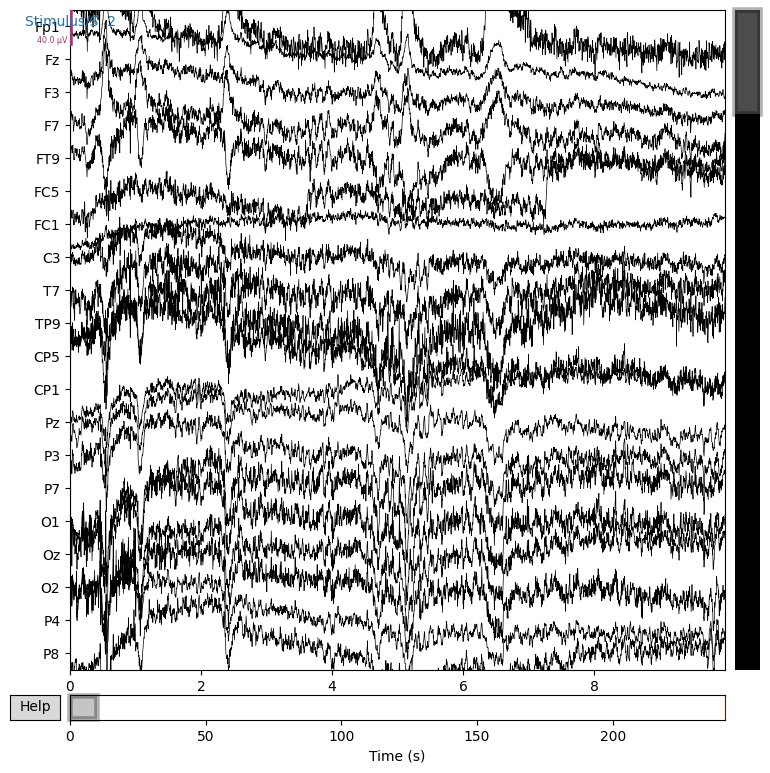

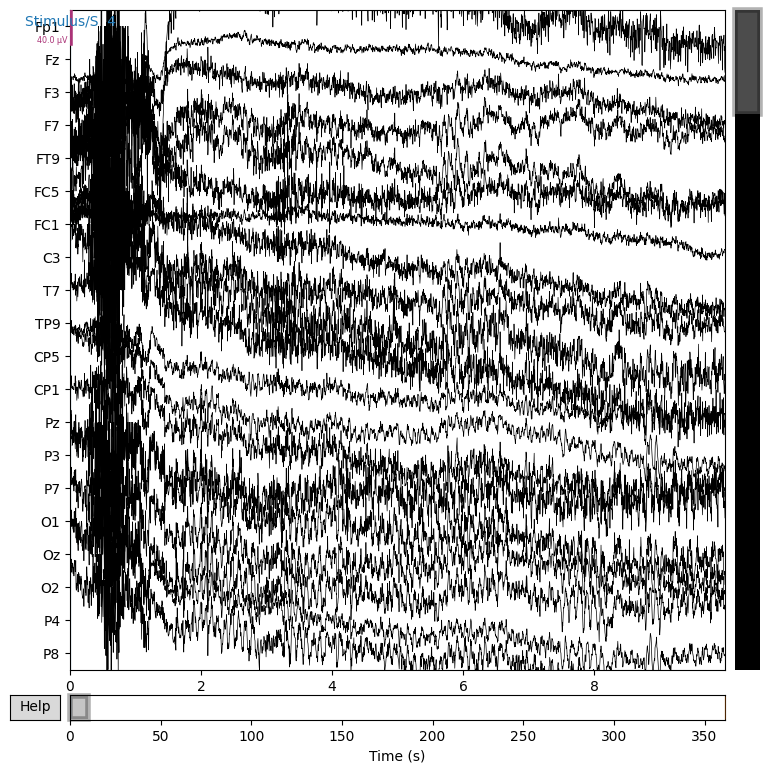

In [10]:
# Quick visual check of the resampled segments
fig_open = raw_eyes_open_resampled.plot(n_channels=20, duration=10)
plt.show()

fig_closed = raw_eyes_closed_resampled.plot(n_channels=20, duration=10)
plt.show()


## 4. PREP-style bad-channel detection and rereferencing

- PyPREP is used here as a PREP-style approach to automate robust bad-channel detection, interpolation, and rereferencing.
- In the full PREP pipeline, line-noise removal can also be handled internally. In this notebook, line-noise removal was carried out explicitly above, so the PREP stage is being used mainly for robust referencing and channel cleaning on the resampled data.
- The pipeline iteratively identifies noisy EEG channels, computes a cleaner reference excluding those channels, interpolates channels judged to be bad, and then recomputes the reference.
- Running this separately on the eyes-open and eyes-closed segments provides a reproducible way to standardise the recordings before creating the `1-40 Hz` filtered branch.


In [11]:
# Set PREP parameters.
# line_freqs is left empty here because line-noise removal was already applied above.
montage = raw.get_montage()

prep_params = {
    "ref_chs": "eeg",
    "reref_chs": "eeg",
    "line_freqs": [],
    "max_iterations": 4,
}


In [ ]:
# Run PREP-style robust channel cleaning and rereferencing on the eyes-open segment
prep_open = PrepPipeline(
    raw_eyes_open_resampled.copy(),
    prep_params=prep_params,
    montage=montage,
    ransac=True,
    random_state=42,
)
prep_open.fit()
raw_eyes_open_prep = prep_open.raw_eeg

print("Eyes open interpolated channels:", prep_open.interpolated_channels)
print("Eyes open channels still noisy after interpolation:", prep_open.still_noisy_channels)


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)



In [ ]:
# Run PREP-style robust channel cleaning and rereferencing on the eyes-closed segment
prep_closed = PrepPipeline(
    raw_eyes_closed_resampled.copy(),
    prep_params=prep_params,
    montage=montage,
    ransac=True,
    random_state=42,
)
prep_closed.fit()
raw_eyes_closed_prep = prep_closed.raw_eeg

print("Eyes closed interpolated channels:", prep_closed.interpolated_channels)
print("Eyes closed channels still noisy after interpolation:", prep_closed.still_noisy_channels)


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/72 [00:00<?,       ?it/s]


RANSAC done!


2026-08-01 17:59:02,055 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': ['Cz', 'FFC2h', 'FCC2h'], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': [], 'bad_by_ransac': [], 'bad_by_manual': [], 'bad_all': ['FFC2h', 'FCC2h', 'Cz']}


Executing RANSAC
This may take a while, so be patient...


...

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 117 sensor positions
Interpolating 10 sensors
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/72 [00:00<?,       ?it/s]


RANSAC done!
Found 8 uniquely bad channels:

0 by NaN: []

0 by flat: []

0 by deviation: []

0 by HF noise: []

1 by correlation: ['TP10']

0 by SNR: []

0 by dropout: []

8 by PSD: ['Fp1', 'TP10', 'AF3', 'AF4', 'AFp1', 'AFF5h', 'TPP9h', 'AFF6h']

0 by RANSAC: []

0 by manual: []

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 119 sensor positions
Interpolating 8 sensors
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/72 [00:00<?,       ?it/s]


RANSAC done!
Eyes closed interpolated channels: ['AFp1', 'AF3', 'AFF5h', 'AFF6h', 'TP10', 'AF4', 'TPP9h', 'Fp1']
Eyes closed channels still noisy after interpolation: ['PPO9h', 'TP9', 'F6', 'P5', 'F4']


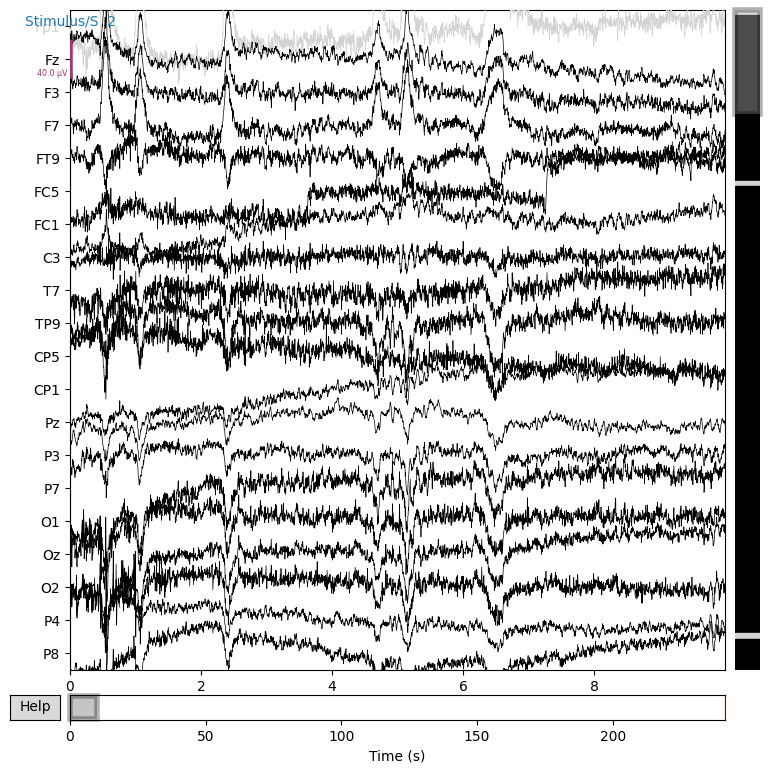

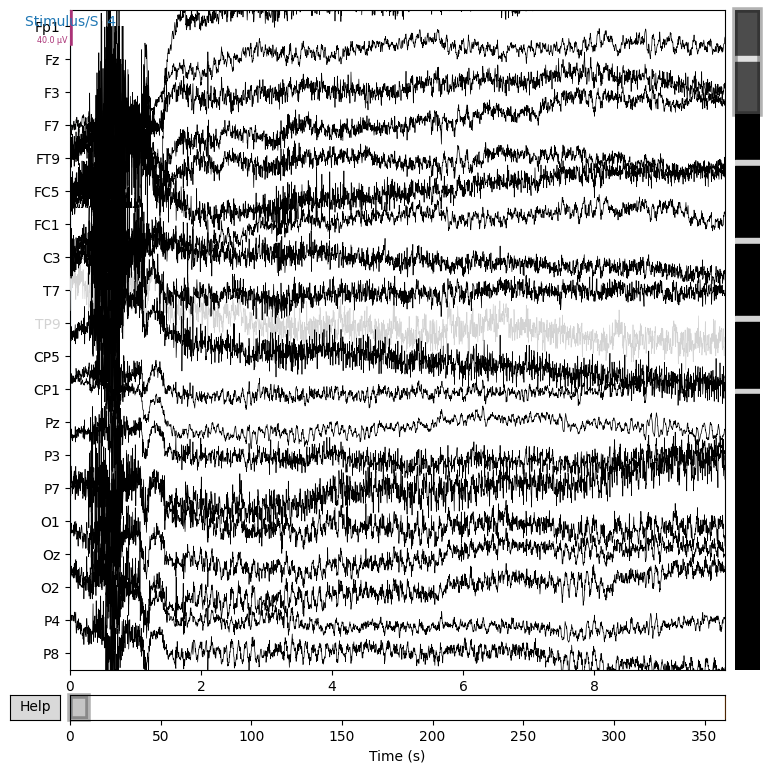

In [ ]:
# Quick visual check after PREP-style cleaning
raw_eyes_open_prep.plot(n_channels=20, duration=10)
plt.show()

raw_eyes_closed_prep.plot(n_channels=20, duration=10)
plt.show()


## 5. Band-pass filter

- A `1-40 Hz` band-pass filter is applied to PREP-cleaned data.
- This dataset will be suitable for later ICA-based artifact correction and preserves the frequency range currently planned for resting-state spectral power features.
- PSD is compared before preprocessing and after line-noise removal, PREP-style channel cleaning, and `1-40 Hz` filtering.


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 4

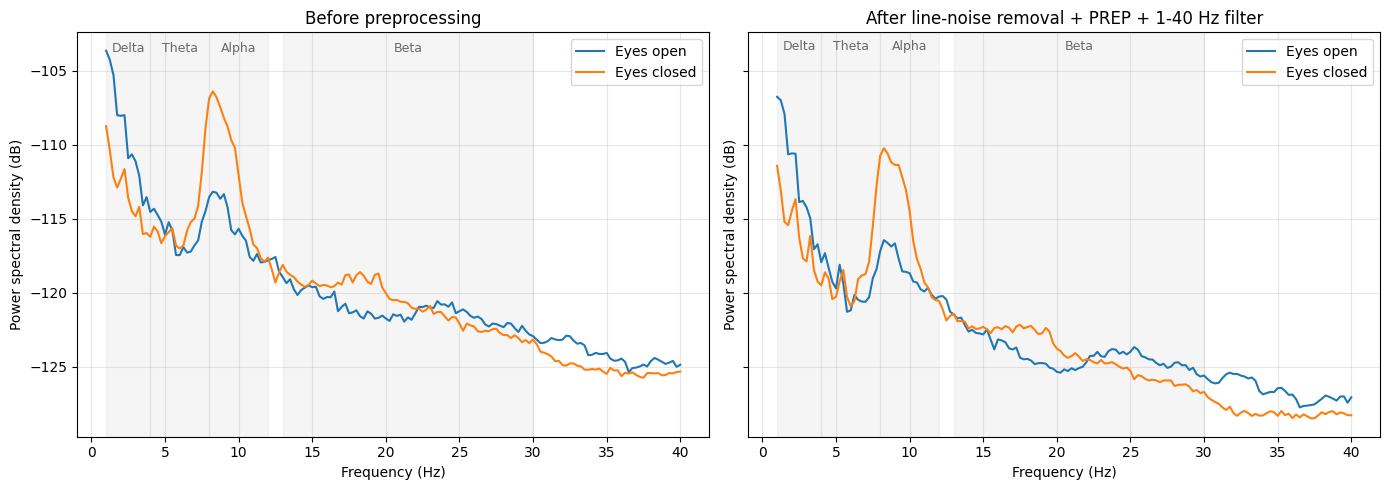

In [ ]:
# Create a single 1-40 Hz branch from the PREP-cleaned data
raw_eyes_open_1_40 = raw_eyes_open_prep.copy().filter(l_freq=1, h_freq=40)
raw_eyes_closed_1_40 = raw_eyes_closed_prep.copy().filter(l_freq=1, h_freq=40)

# Compare PSD before preprocessing vs after line-noise removal + PREP + 1-40 Hz filtering
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_psd_comparison(
    raw_eyes_open,
    raw_eyes_closed,
    fmin=1,
    fmax=40,
    title="Before preprocessing",
    ax=axes[0],
)

plot_psd_comparison(
    raw_eyes_open_1_40,
    raw_eyes_closed_1_40,
    fmin=1,
    fmax=40,
    title="After line-noise removal + PREP + 1-40 Hz filter",
    ax=axes[1],
)

plt.tight_layout()
plt.savefig("../figures/exploratory/sub-01_rest_psd_preprocessing_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. ICA-based artifact correction

- ICA is run on the continuous `1-40 Hz` data after line-noise removal, resampling, PREP-style bad-channel handling, and rereferencing.
- The aim is to identify recurring artifact components such as blinks, eye movements, heartbeat, or muscle activity.
- For this first pass, ICA is limited to `50` components to make inspection more manageable.
- MNE's `ica.find_bads_eog()` is used with frontal EEG channels as EOG proxies, because this dataset does not appear to include dedicated EOG channels.
- Fixed-length epoching and bad-epoch rejection will be added after ICA once the artifact-component decisions are clearer.


In [ ]:
# Fit ICA separately for eyes-open and eyes-closed continuous segments

rank = mne.compute_rank(raw_eyes_open_1_40, tol='auto')
print(rank)

ica_params = {
    "n_components": None,
    "method": "fastica",
    "max_iter": "auto",
    "random_state": 7,
}

ica_open = ICA(**ica_params)
ica_closed = ICA(**ica_params)

ica_open.fit(raw_eyes_open_1_40)
ica_closed.fit(raw_eyes_closed_1_40)

print(f"Eyes-open ICA components: {ica_open.n_components_}")
print(f"Eyes-closed ICA components: {ica_closed.n_components_}")


Computing rank from data with rank=None
    Using tolerance 4.3e-11 (2.2e-16 eps * 124 dim * 1.6e+03  max singular value)
    Estimated rank (eeg): 114
    EEG: rank 114 computed from 124 data channels with 0 projectors
{'eeg': 114}
Fitting ICA to data using 124 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 114 components
Fitting ICA took 8.7s.
Fitting ICA to data using 122 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 117 components
Fitting ICA took 21.6s.
Eyes-open ICA components: 114
Eyes-closed ICA components: 117


### Save ICA component figures for review

- Component topographies are saved to `figures/exploratory/ica/` so they can be reviewed outside the notebook.
- Use these figures to decide which component numbers should be added to `ica_open.exclude` and `ica_closed.exclude`.


In [ ]:
# Save ICA component topographies in batches for easier review
ica_fig_dir = project_root / "figures" / "exploratory" / "ica"
ica_fig_dir.mkdir(parents=True, exist_ok=True)

def save_ica_component_batches(ica, label, *, batch_size=20):
    for start in range(0, ica.n_components_, batch_size):
        stop = min(start + batch_size, ica.n_components_)
        picks = list(range(start, stop))
        fig = ica.plot_components(picks=picks, show=False)
        figures = fig if isinstance(fig, list) else [fig]

        for page, one_fig in enumerate(figures, start=1):
            save_path = ica_fig_dir / f"sub-01_rest_{label}_ica_components_{start:02d}_{stop - 1:02d}_page{page}.png"
            one_fig.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(one_fig)
            print(save_path)

save_ica_component_batches(ica_open, "eyes-open")
save_ica_component_batches(ica_closed, "eyes-closed")


/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-open_ica_components_00_19_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-open_ica_components_20_39_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-open_ica_components_40_59_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-open_ica_components_60_79_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-open_ica_components_80_99_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-open_ica_components_100_113_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-closed_ica_components_00_19_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/exploratory/ica/sub-01_rest_eyes-closed_ica_components_20_39_page1.png
/Users/nataliemarryatt/neurogenetics-ml/figures/explorator

### Automated ICA artifact labeling with ICLabel

- For a scalable multi-participant workflow, `mne-icalabel` can classify ICA components as brain, eye, muscle, heart, line noise, channel noise, or other.
- This section uses conservative probability thresholds and creates an ICA-cleaned copy that can be compared against the pre-ICA signal.
- Components labelled as `brain` or low-confidence/uncertain components are not removed automatically.


In [ ]:
# Automated artifact-component labeling for scalable ICA cleaning
# Requires: pip install mne-icalabel
try:
    from mne_icalabel import label_components
except ImportError as exc:
    raise ImportError(
        "mne-icalabel is required for automated ICA labeling. "
        "Install it with `pip install mne-icalabel` and rerun this cell."
    ) from exc

# Conservative thresholds: stricter for muscle/channel/line-noise components.
artifact_thresholds = {
    "eye blink": 0.85,
    "muscle artifact": 0.85,
    "heart beat": 0.85,
    "line noise": 0.85,
    "channel noise": 0.85,
}

def get_icalabel_artifact_components(raw, ica, thresholds):
    labels = label_components(raw, ica, method="iclabel") # run IC label on fitted ICA component
    component_labels = labels["labels"]
    component_probs = labels["y_pred_proba"]
    artifact_components = []

    for idx, (label, prob) in enumerate(zip(component_labels, component_probs)):
        threshold = thresholds.get(label)
        if threshold is not None and prob >= threshold:
            artifact_components.append(idx)

    summary = [
        {"component": idx, "label": label, "probability": float(prob)}
        for idx, (label, prob) in enumerate(zip(component_labels, component_probs))
    ]
    return artifact_components, summary

icalabel_open_auto, icalabel_open_summary = get_icalabel_artifact_components(
    raw_eyes_open_1_40, ica_open, artifact_thresholds
)
icalabel_closed_auto, icalabel_closed_summary = get_icalabel_artifact_components(
    raw_eyes_closed_1_40, ica_closed, artifact_thresholds
)

print("Eyes-open ICLabel artifact candidates:", icalabel_open_auto)
print("Eyes-closed ICLabel artifact candidates:", icalabel_closed_auto)

display(
    pd.DataFrame(icalabel_open_summary)
    .query("component in @icalabel_open_auto")
    .sort_values("probability", ascending=False)
)
display(
    pd.DataFrame(icalabel_closed_summary)
    .query("component in @icalabel_closed_auto")
    .sort_values("probability", ascending=False)
)


/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_47792/689312360.py:21: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_47792/689312360.py:21: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/var/folders/d8/d9glxz0d5vs6ljllsgnfkrpr0000gn/T/ipykernel_47792/689312360.py:21: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infoma

Eyes-open ICLabel artifact candidates: [0, 7, 17, 19, 84, 97, 100, 111]
Eyes-closed ICLabel artifact candidates: [5, 10, 18, 26, 66, 84, 105]


,component,label,probability
17,17,muscle artifact,0.993238
84,84,channel noise,0.992235
97,97,channel noise,0.981231
7,7,eye blink,0.966038
111,111,channel noise,0.955217
0,0,eye blink,0.934477
19,19,eye blink,0.904443
100,100,channel noise,0.874061


,component,label,probability
26,26,muscle artifact,0.998117
10,10,eye blink,0.992686
18,18,muscle artifact,0.989272
5,5,eye blink,0.963305
84,84,channel noise,0.959305
105,105,channel noise,0.886315
66,66,channel noise,0.872716


In [ ]:
# Apply the ICLabel-based automated exclusions to separate comparison copies
ica_open_icalabel = ica_open.copy()
ica_closed_icalabel = ica_closed.copy()

ica_open_icalabel.exclude = sorted(set(icalabel_open_auto))
ica_closed_icalabel.exclude = sorted(set(icalabel_closed_auto))

raw_eyes_open_icalabel = raw_eyes_open_1_40.copy()
raw_eyes_closed_icalabel = raw_eyes_closed_1_40.copy()

ica_open_icalabel.apply(raw_eyes_open_icalabel)
ica_closed_icalabel.apply(raw_eyes_closed_icalabel)

print("Eyes-open ICLabel components excluded:", ica_open_icalabel.exclude)
print("Eyes-closed ICLabel components excluded:", ica_closed_icalabel.exclude)


Applying ICA to Raw instance
    Transforming to ICA space (114 components)
    Zeroing out 8 ICA components
    Projecting back using 124 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (117 components)
    Zeroing out 7 ICA components
    Projecting back using 122 PCA components
Eyes-open ICLabel components excluded: [0, 7, 17, 19, 84, 97, 100, 111]
Eyes-closed ICLabel components excluded: [5, 10, 18, 26, 66, 84, 105]


NameError: name 'raw_eyes_open_1_40' is not defined

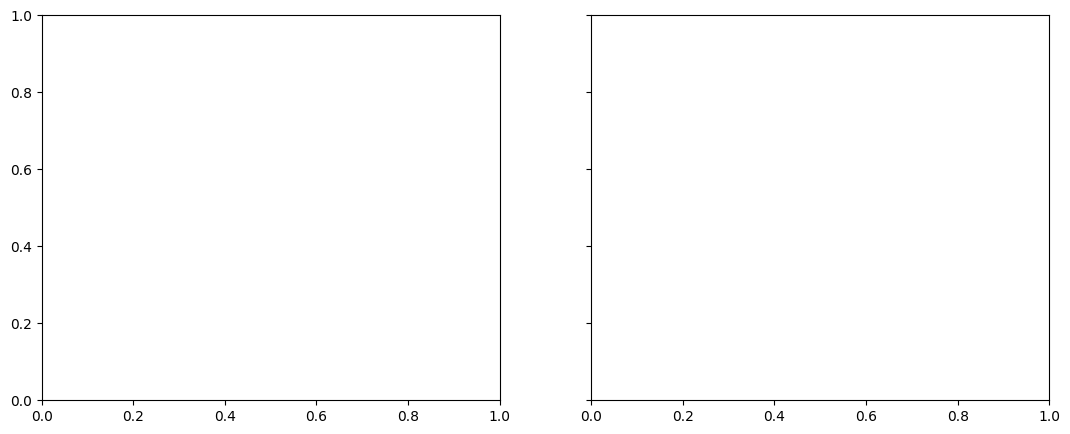

In [ ]:
# Compare the filtered signal before ICA with the ICLabel-cleaned signal after ICA.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

plot_psd_comparison(
    raw_eyes_open_1_40,
    raw_eyes_closed_1_40,
    fmin=1,
    fmax=40,
    title="Before ICA",
    ax=axes[0],
)

plot_psd_comparison(
    raw_eyes_open_icalabel,
    raw_eyes_closed_icalabel,
    fmin=1,
    fmax=40,
    title="After ICLabel ICA",
    ax=axes[1],
)

fig.suptitle("Resting EEG PSD before and after ICA cleaning", y=1.02)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("../figures/exploratory/sub-01_rest_psd_icalabel_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Epoching and bad segment rejection


- Fixed-length epochs are created from the ICA-cleaned continuous resting-state data.
- Bad segments are rejected with MNE's peak-to-peak amplitude criteria, using EEG thresholds in volts because MNE stores EEG internally as volts.
- Epoching is run separately for eyes-open and eyes-closed data so each condition keeps its own rejection summary.


In [ ]:
# Fixed-length epoching parameters for cleaned resting-state EEG
epoch_duration_s = 2.0
epoch_overlap_s = 0.0

# MNE EEG data are in volts. 150e-6 V = 150 uV; 1e-6 V = 1 uV.
reject_criteria = {"eeg": 150e-6}
flat_criteria = {"eeg": 1e-6}

def make_clean_rest_epochs(raw_clean, *, condition_label):
    raw_for_epoch = raw_clean.copy().pick("eeg", exclude="bads")
    excluded_bads = sorted(set(raw_clean.info["bads"]) - set(raw_for_epoch.ch_names))
    if excluded_bads:
        print(f"{condition_label}: excluding bad channels from epoch rejection: {excluded_bads}")

    epochs = mne.make_fixed_length_epochs(
        raw_for_epoch,
        duration=epoch_duration_s,
        overlap=epoch_overlap_s,
        preload=True,
        reject_by_annotation=True,
    )
    n_before = len(epochs)
    epochs.drop_bad(reject=reject_criteria, flat=flat_criteria)
    n_after = len(epochs)
    n_dropped = n_before - n_after
    drop_percent = 100 * n_dropped / n_before if n_before else 0

    print(f"{condition_label}: {n_after}/{n_before} epochs retained ({drop_percent:.1f}% dropped)")
    return epochs


In [ ]:
# Create final epochs from the ICLabel-cleaned ICA branch
epochs_eyes_open_clean = make_clean_rest_epochs(
    raw_eyes_open_icalabel,
    condition_label="Eyes open",
)
epochs_eyes_closed_clean = make_clean_rest_epochs(
    raw_eyes_closed_icalabel,
    condition_label="Eyes closed",
)

epoch_qc = pd.DataFrame(
    [
        {
            "condition": "eyes_open",
            "n_epochs": len(epochs_eyes_open_clean),
            "duration_s": epoch_duration_s,
            "reject_eeg_uv": reject_criteria["eeg"] * 1e6,
            "flat_eeg_uv": flat_criteria["eeg"] * 1e6,
        },
        {
            "condition": "eyes_closed",
            "n_epochs": len(epochs_eyes_closed_clean),
            "duration_s": epoch_duration_s,
            "reject_eeg_uv": reject_criteria["eeg"] * 1e6,
            "flat_eeg_uv": flat_criteria["eeg"] * 1e6,
        },
    ]
)

display(epoch_qc)


Eyes open: excluding bad channels from epoch rejection: ['AF3', 'FCC6h', 'Fp1']
Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 500 original time points ...
0 bad epochs dropped
    Rejecting  epoch based on EEG : ['F3', 'F7', 'FC5', 'C3', 'T7', 'FC6', 'F8', 'F5', 'FT7', 'FC3', 'C5', 'FC4', 'F6', 'AF8', 'F9', 'FFC5h', 'FTT7h', 'FFC6h', 'AFF5h', 'FFT9h', 'FFT7h', 'FCC5h', 'FFT8h']
1 bad epochs dropped
Eyes open: 119/120 epochs retained (0.8% dropped)
Eyes closed: excluding bad channels from epoch rejection: ['F4', 'F6', 'P5', 'PPO9h', 'TP9']
Not setting metadata
180 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 180 events and 500 original time points ...
0 bad epochs dropped
    Rejecting  epoch based on EEG : ['Fp1', 'F7', 'FT9', 'FC5', 'C3', 'T7', 'T8', 'FC6', 'F8', 'Fp2', 'AF7', 'AF3', 'F5', 'FT7', 'FC3', 'C5

,condition,n_epochs,duration_s,reject_eeg_uv,flat_eeg_uv
0,eyes_open,119,2.0,150.0,1.0
1,eyes_closed,179,2.0,150.0,1.0
